Import required libraries

In [3]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet  
from sklearn.model_selection import KFold

Data loading and standardization

In [4]:
X_raw = np.loadtxt("dataF_final.csv", delimiter=",")
Y_raw = np.loadtxt("dataC_final.csv", delimiter=",")

if Y_raw.ndim == 1:
    Y_raw = Y_raw.reshape(-1, 1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(X_raw)
Y = scaler_y.fit_transform(Y_raw)

Cross-validated RMSE for subset evaluation

Used inside the CARS algorithm to track the optimal subset

In [5]:
def cv_rmse(X, y, n_components=6):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    comp = min(n_components, X.shape[1], X.shape[0]-1)
    model = PLSRegression(n_components=comp)

    for tr, te in kf.split(X):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))

    return np.mean(rmses)

VIP calculation function

In [6]:
def compute_vip(pls, X, y):
   
    T = pls.x_scores_
    W = pls.x_weights_
    Q = pls.y_loadings_

    p, h = W.shape
    s = np.diag(T.T @ T @ Q.T @ Q).reshape(h, -1)
    total_s = np.sum(s)

    vip = np.zeros(p)
    for i in range(p):
        weight = np.array([(W[i, j] ** 2) * s[j] for j in range(h)])
        vip[i] = np.sqrt(p * np.sum(weight) / total_s)

    return vip

Variable Importance in Projection (VIP)

VIP ranks variables based on their contribution to explaining the response variance.Variables were ranked by VIP score and the top 20% most informative features were retained to improve model performance and reduce noise.

In [16]:
def vip_selection(X, y_single, vip_threshold=1.0):
   
    n_comp = min(20, X.shape[1], X.shape[0]-1)
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y_single)

    vip_scores = compute_vip(pls, X, y_single)

    # keep top 20% VIP variables ONLY
    k = int(0.2 * len(vip_scores))
    selected_idx = np.argsort(-vip_scores)[:k]

    return selected_idx

Regression models and cross-validation

In [17]:
results_list = []
all_predictions = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

test_models = {
    "PLSR": PLSRegression(n_components=6),
    "Ridge": Ridge(alpha=300),
    "Lasso": Lasso(alpha=0.05),
    "ElasticNet": ElasticNet(alpha=0.5, l1_ratio=0.01)
}


Model evaluation using 5-fold cross-validation


In [18]:

print(f"{'Target':<8} | {'Model':<12} | {'R2_test':<10} | {'RMSE_test':<10} | {'Features':<8}")
print("-" * 75)

for t in range(Y.shape[1]):
    print(f"\nOptimizing Target {t+1}...")
    start = time.time()

    best_idx = vip_selection(X, Y[:,t])
    X_selected = X[:, best_idx]
    y_target = Y[:, t]

    fold_scores = {name: {"r2": [], "rmse": []} for name in test_models}
    temp_true = {name: [] for name in test_models}
    temp_pred = {name: [] for name in test_models}

    for train_idx, test_idx in kf.split(X_selected):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_target[train_idx], y_target[test_idx]

        for name, model in test_models.items():

            if name == "PLSR":
                model.n_components = min(6, X_selected.shape[1])

            model.fit(X_train, y_train)
            pred = model.predict(X_test).flatten()

            temp_true[name].extend(y_test)
            temp_pred[name].extend(pred)

            fold_scores[name]["r2"].append(r2_score(y_test, pred))
            fold_scores[name]["rmse"].append(np.sqrt(mean_squared_error(y_test, pred)))

    for name in test_models:
        mean_r2 = np.mean(fold_scores[name]["r2"])
        mean_rmse = np.mean(fold_scores[name]["rmse"])

        results_list.append({
            "Target": t+1,
            "Model": name,
            "R2_test": mean_r2,
            "RMSE_test": mean_rmse,
            "Features": len(best_idx)
        })

        all_predictions[(t+1, name)] = (
            np.array(temp_true[name]),
            np.array(temp_pred[name])
        )

        print(f"T{t+1:<6} | {name:<12} | {mean_r2:.4f} | {mean_rmse:.4f} | {len(best_idx):<8}")

    print(f"RunTime: {time.time() - start:.2f}s")

Target   | Model        | R2_test    | RMSE_test  | Features
---------------------------------------------------------------------------

Optimizing Target 1...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.854e-01, tolerance: 2.025e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.738e-02, tolerance: 2.109e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.330e-01, tolerance: 1.9

T1      | PLSR         | 0.4227 | 0.7485 | 373     
T1      | Ridge        | 0.4560 | 0.7301 | 373     
T1      | Lasso        | 0.3485 | 0.7991 | 373     
T1      | ElasticNet   | 0.4507 | 0.7327 | 373     
RunTime: 0.49s

Optimizing Target 2...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.243e+00, tolerance: 2.065e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.551e-01, tolerance: 2.049e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.010e+00, tolerance: 1.9

T2      | PLSR         | 0.4691 | 0.7239 | 373     
T2      | Ridge        | 0.4974 | 0.7059 | 373     
T2      | Lasso        | 0.3900 | 0.7782 | 373     
T2      | ElasticNet   | 0.4856 | 0.7137 | 373     
RunTime: 0.51s

Optimizing Target 3...
T3      | PLSR         | 0.3800 | 0.7307 | 373     
T3      | Ridge        | 0.3971 | 0.7355 | 373     
T3      | Lasso        | 0.2737 | 0.8123 | 373     
T3      | ElasticNet   | 0.3996 | 0.7260 | 373     
RunTime: 0.33s

Optimizing Target 4...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.756e-01, tolerance: 1.964e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.398e-01, tolerance: 1.872e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.950e-01, tolerance: 2.0

T4      | PLSR         | 0.4780 | 0.7066 | 373     
T4      | Ridge        | 0.5069 | 0.6934 | 373     
T4      | Lasso        | 0.4243 | 0.7488 | 373     
T4      | ElasticNet   | 0.5025 | 0.6936 | 373     
RunTime: 0.51s

Optimizing Target 5...
T5      | PLSR         | -0.1746 | 0.9427 | 373     
T5      | Ridge        | 0.0686 | 0.8829 | 373     
T5      | Lasso        | -0.0998 | 0.9599 | 373     
T5      | ElasticNet   | -0.0129 | 0.9033 | 373     
RunTime: 0.31s


Best Model Per Target (VIP)

In [97]:
results_df_cars = pd.DataFrame(results_list)

best_models_cars = (
    results_df_cars.sort_values("RMSE_test")
    .groupby("Target")
    .first()
    .reset_index()
)

best_models_cars

,Target,Model,R2_test,RMSE_test,Features
0,1,Ridge,0.444251,0.737184,895
1,2,PLSR,0.493810,0.706187,881
2,3,Ridge,0.390880,0.731119,895
3,4,Ridge,0.510917,0.688074,905
4,5,Ridge,0.088829,0.873197,877


Predicted vs Observed for best model per target

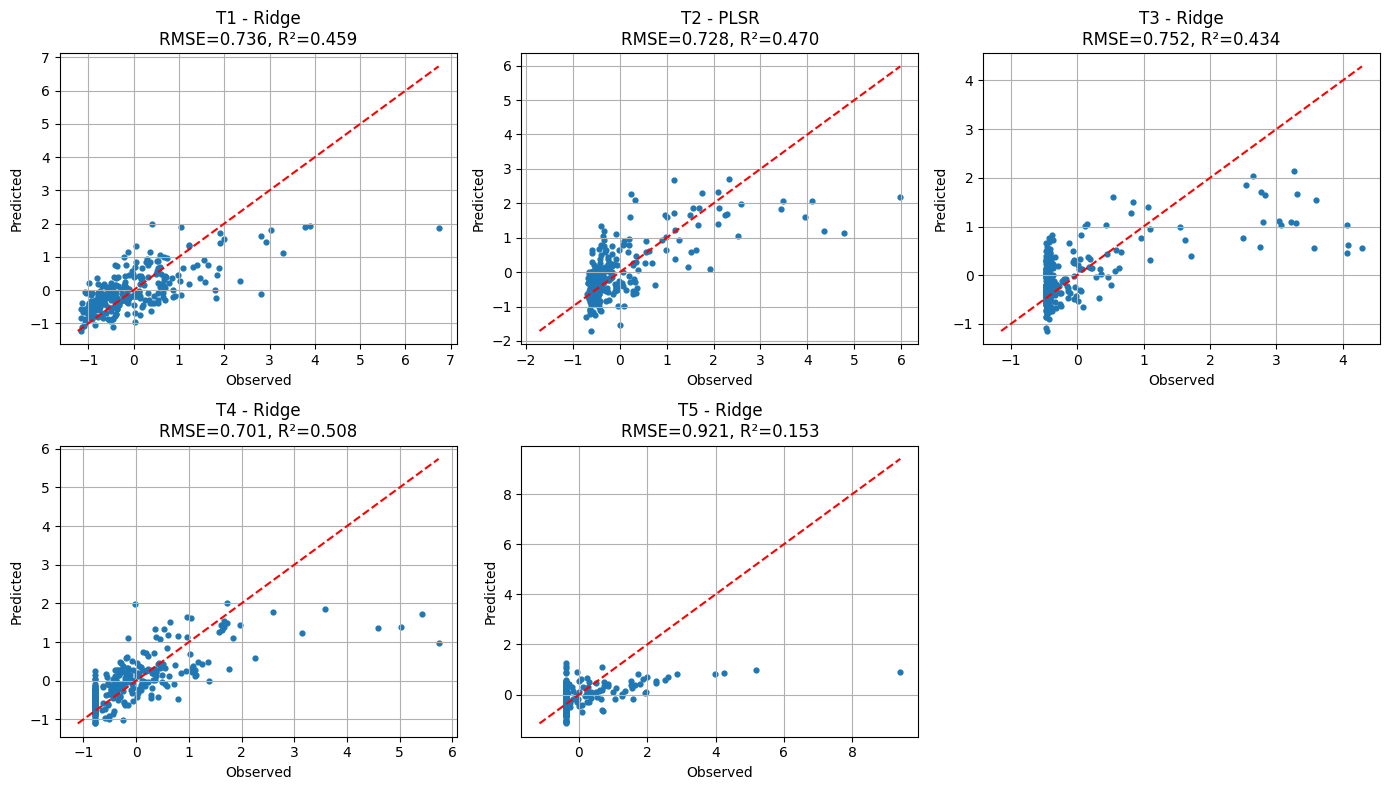

In [114]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def plot_best_models(best_models, all_predictions):
    
    cols = 3
    rows = int(np.ceil(len(best_models) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for i, row in best_models.iterrows():
        t = row["Target"]
        model = row["Model"]

        y_true, y_pred = all_predictions[(t, model)]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        plt.subplot(rows, cols, i + 1)
        plt.scatter(y_true, y_pred, s=12)

        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        plt.plot([min_v, max_v], [min_v, max_v], "r--")

        plt.title(f"T{t} - {model}\nRMSE={rmse:.3f}, R²={r2:.3f}")
        plt.xlabel("Observed")
        plt.ylabel("Predicted")
        plt.grid()

    plt.tight_layout()
    plt.show()
    
plot_best_models(best_models_cars, all_predictions)